### Intentional Error Replication - Digit Recognizer (MNIST)
### Based on the Kaggle CNN approach, but with deliberate mistakes
### to study how reproducibility can fail in practice.

AI Usage:I used AI tools to identify and resolve syntax issues and coding errors encountered during development. Additionally, AI was used to assist in drafting and refining the summary section.


## 1. Import libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop

In [35]:
# Reproducibility seed
np.random.seed(42)
tf.random.set_seed(42)


## 2. Load the data

In [37]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample_submission = pd.read_csv("data/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (42000, 785)
Test shape: (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2.1 Separate labels from training features

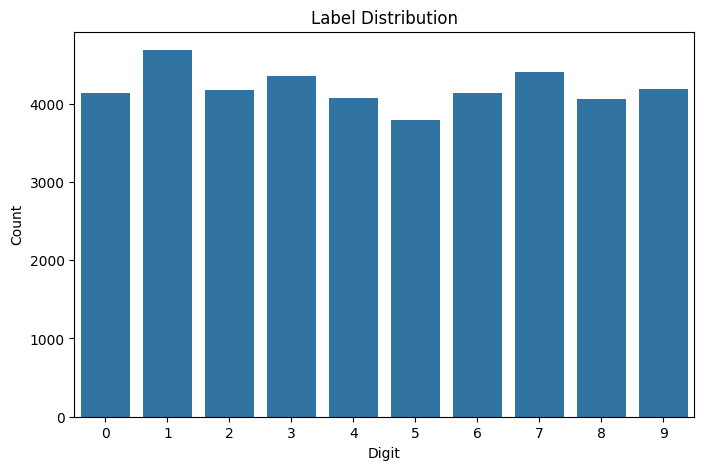

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


In [38]:
# Separate labels from training features
Y_train = train["label"]
X_train = train.drop(labels=["label"], axis=1)

# Check label distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=Y_train)
plt.title("Label Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

print(Y_train.value_counts().sort_index())

The training set is fairly balanced across all digit classes, so there is no major class imbalance issue at the start of the experiment.

## 2.2 Check for null and missing values

In [39]:
# Check missing values in training data
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in test:")
print(test.isnull().sum().sum())

Missing values in X_train:
0

Missing values in test:
0


There are no missing values in either the training or test data, so the dataset is ready for preprocessing.

## 2.3 Normalization

In [40]:
# INTENTIONAL ERROR:
# In the original notebook, pixel values are divided by 255 to scale them to [0,1].
# Here that step is intentionally skipped to study how this affects reproducibility.

X_train = X_train
test = test

In the original implementation, normalization helps the model train more smoothly because the pixel values are scaled to a smaller range. In this version, that step is intentionally skipped. This reflects a common implementation mistake where a re-creator follows the architecture correctly but misses an important preprocessing detail.

## 2.4 Reshape

In [41]:
# Reshape images to 28x28x1 for CNN input
X_train = X_train.values.reshape(-1, 28, 28, 1)
test = test.values.reshape(-1, 28, 28, 1)

print("X_train shape after reshape:", X_train.shape)
print("Test shape after reshape:", test.shape)

X_train shape after reshape: (42000, 28, 28, 1)
Test shape after reshape: (28000, 28, 28, 1)


The original digit images are stored as flat vectors of length 784. They are reshaped into 28 × 28 × 1 format so they can be used as grayscale image inputs for the convolutional neural network.

## 2.5 Label encoding

In [42]:
# Convert labels to one-hot encoding
Y_train = to_categorical(Y_train, num_classes=10)

print("Encoded label shape:", Y_train.shape)

Encoded label shape: (42000, 10)


The labels are converted into one-hot encoded vectors because the model is solving a 10-class classification problem.

## 2.6 Split training and validation set

In [43]:
# Split the data into training and validation sets
random_seed = 2

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.10,
    random_state=random_seed
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

Training set shape: (37800, 28, 28, 1)
Validation set shape: (4200, 28, 28, 1)


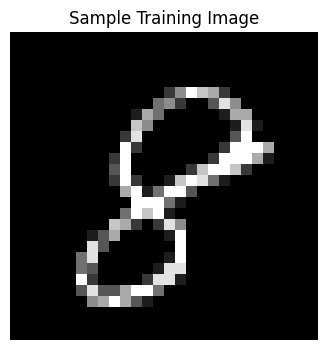

In [44]:
# Show one sample image
plt.figure(figsize=(4, 4))
plt.imshow(X_train[0][:, :, 0], cmap="gray")
plt.title("Sample Training Image")
plt.axis("off")
plt.show()

A 90:10 split is used so that most of the data is available for training while a smaller portion is kept aside for validation. The validation set helps measure how well the model performs on unseen examples.

# 3. CNN
## 3.1 Define the model

In [45]:
# Define the CNN model
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='Same',
                 activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='Same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='Same',
                 activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='Same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 887,530 (3.39 MB)

 Trainable params: 887,530 (3.39 MB)

 Non-trainable params: 0 (0.00 B)

The network structure is kept close to the original notebook so that the main difference in performance comes from training choices rather than a completely different architecture.

## 3.2 Set the optimizer

In [46]:
# INTENTIONAL ERROR:
# The learning rate here is intentionally set higher than the original setup.
# This can make training less stable and may reduce final performance.

optimizer = RMSprop(learning_rate=0.01, rho=0.9, epsilon=1e-08)

In [47]:
# Compile the model
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

The optimizer plays a major role in training quality. In this version, the learning rate is intentionally increased beyond the original setting. This is a realistic reimplementation mistake because tuning details are often not reproduced carefully, even when the model design itself is copied correctly.

## 3.3 No annealer and no data augmentation

In [48]:
# INTENTIONAL ERRORS:
# 1. No learning rate annealer is used
# 2. No data augmentation is used
# 3. Batch size is made larger than the original

epochs = 10
batch_size = 256

In [49]:
# Train the model directly without augmentation
history = model.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, Y_val),
    verbose=2
)

Epoch 1/10
148/148 - 27s - 185ms/step - accuracy: 0.6155 - loss: 65.4334 - val_accuracy: 0.8676 - val_loss: 0.4090
Epoch 2/10
148/148 - 27s - 184ms/step - accuracy: 0.8423 - loss: 0.7373 - val_accuracy: 0.9133 - val_loss: 0.3965
Epoch 3/10
148/148 - 28s - 190ms/step - accuracy: 0.8946 - loss: 0.4362 - val_accuracy: 0.9467 - val_loss: 0.1788
Epoch 4/10
148/148 - 29s - 195ms/step - accuracy: 0.8982 - loss: 0.4126 - val_accuracy: 0.9405 - val_loss: 0.2486
Epoch 5/10
148/148 - 28s - 192ms/step - accuracy: 0.9098 - loss: 0.3759 - val_accuracy: 0.9260 - val_loss: 0.2934
Epoch 6/10
148/148 - 28s - 191ms/step - accuracy: 0.9084 - loss: 0.3548 - val_accuracy: 0.9436 - val_loss: 0.2020
Epoch 7/10
148/148 - 29s - 193ms/step - accuracy: 0.9068 - loss: 0.3617 - val_accuracy: 0.9395 - val_loss: 0.2626
Epoch 8/10
148/148 - 29s - 194ms/step - accuracy: 0.9082 - loss: 0.3515 - val_accuracy: 0.9493 - val_loss: 0.1678
Epoch 9/10
148/148 - 30s - 203ms/step - accuracy: 0.9109 - loss: 0.3396 - val_accuracy:

The original notebook uses training improvements such as learning rate reduction and data augmentation. In this version, both are intentionally removed. The model is still trained on the same problem, but the setup is less careful and therefore more likely to show weaker reproducibility.

# 4. Evaluate the model
## 4.1 Training and validation curves

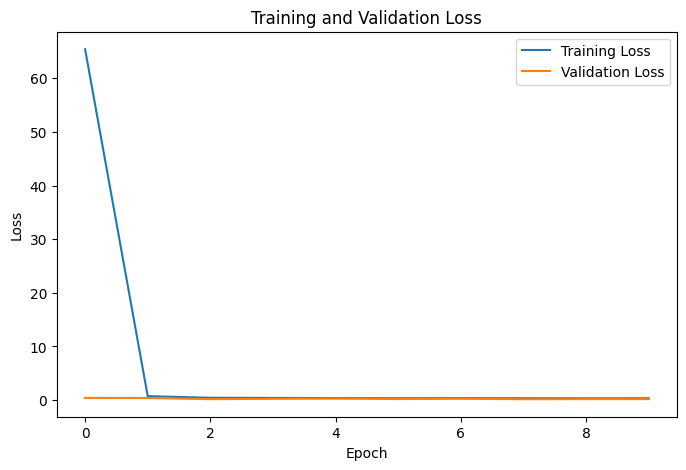

In [50]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

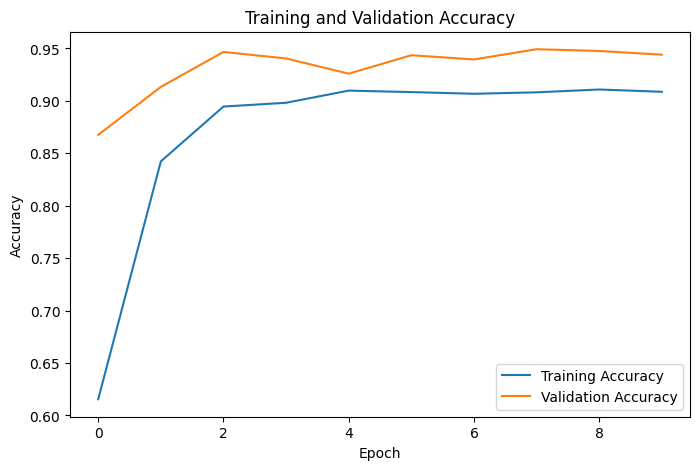

In [51]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

These curves help show whether the model is learning steadily or struggling because of the intentional changes. Since normalization, augmentation, and learning rate scheduling were removed, the training behavior may be less stable than the original implementation.

## 4.2 Confusion matrix

In [52]:
# Predict on validation set
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 


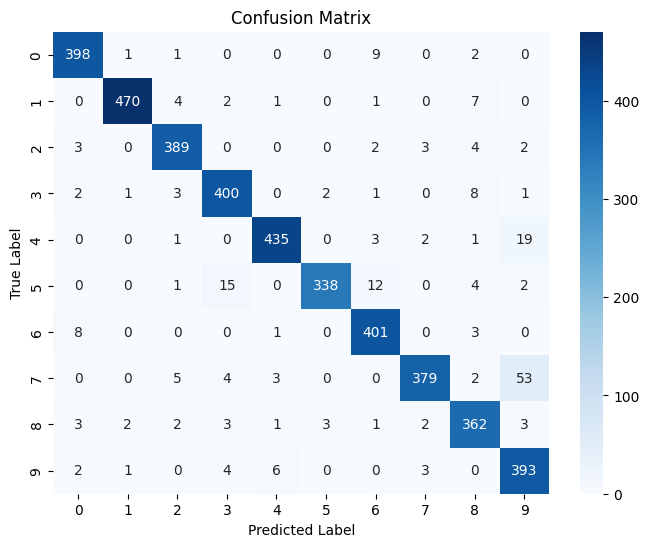

In [54]:
# Confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [55]:
# Classification report
print(classification_report(Y_true, Y_pred_classes))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       411
           1       0.99      0.97      0.98       485
           2       0.96      0.97      0.96       403
           3       0.93      0.96      0.95       418
           4       0.97      0.94      0.96       461
           5       0.99      0.91      0.95       372
           6       0.93      0.97      0.95       413
           7       0.97      0.85      0.91       446
           8       0.92      0.95      0.93       382
           9       0.83      0.96      0.89       409

    accuracy                           0.94      4200
   macro avg       0.95      0.94      0.94      4200
weighted avg       0.95      0.94      0.94      4200



The confusion matrix shows which digits are most often confused with each other. This is useful because it gives a more detailed view than accuracy alone and helps explain where the model becomes less reliable.

## 4.3 Display some error results

In [56]:
# Identify misclassified samples
errors = (Y_pred_classes - Y_true != 0)

Y_pred_classes_errors = Y_pred_classes[errors]
Y_pred_errors = Y_pred[errors]
Y_true_errors = Y_true[errors]
X_val_errors = X_val[errors]

In [57]:
# Find the most confident wrong predictions
Y_pred_errors_prob = np.max(Y_pred_errors, axis=1)
true_prob_errors = np.array([Y_pred_errors[i][Y_true_errors[i]] for i in range(len(Y_true_errors))])
delta_pred_true_errors = Y_pred_errors_prob - true_prob_errors

sorted_dela_errors = np.argsort(delta_pred_true_errors)
most_important_errors = sorted_dela_errors[-6:]

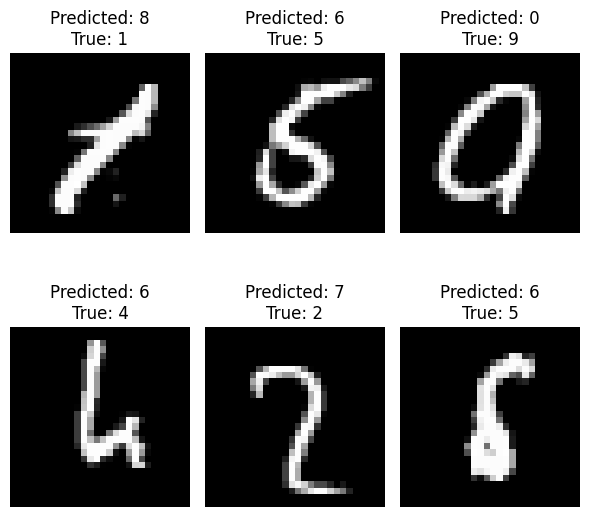

In [61]:
# Display the most important errors
def display_errors(errors_index, img_errors, pred_errors, obs_errors):
    n = 0
    nrows = 2
    ncols = 3
    fig, ax = plt.subplots(nrows, ncols, figsize=(6, 6))
    
    for row in range(nrows):
        for col in range(ncols):
            error = errors_index[n]
            ax[row, col].imshow(img_errors[error].reshape((28, 28)), cmap="gray")
            ax[row, col].set_title(
                f"Predicted: {pred_errors[error]}\nTrue: {obs_errors[error]}"
            )
            ax[row, col].axis("off")
            n += 1

display_errors(most_important_errors, X_val_errors, Y_pred_classes_errors, Y_true_errors)
plt.tight_layout()
plt.show()

These misclassified examples show that even when the model gives a confident prediction, it can still be wrong. This matters for reproducibility because a weaker implementation may not only reduce accuracy, but also change the type of mistakes the model makes.

# 5. Prediction and submission
## 5.1 Predict and submit results

In [62]:
# Predict test results
results = model.predict(test)
results = np.argmax(results, axis=1)

results = pd.Series(results, name="Label")
submission = pd.concat([pd.Series(range(1, len(results) + 1), name="ImageId"), results], axis=1)

submission.to_csv("intentional_error_submission.csv", index=False)
print("Submission file saved as intentional_error_submission.csv")
submission.head()

875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
Submission file saved as intentional_error_submission.csv


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


# Short Results Summary

This notebook followed the same general CNN pipeline as the original digit recognizer project, but introduced a few small mistakes on purpose. The model architecture stayed similar, but the training setup was weaker because normalization was skipped, the learning rate was increased, data augmentation was removed, and no learning rate annealer was used.

These changes help show why reproducibility in machine learning is not only about copying the model structure. Small differences in preprocessing and training decisions can lead to lower performance and a different error pattern. This makes reproducibility an ethical issue as well, because unclear implementation details can make strong results difficult for others to reproduce honestly and consistently.